# USE THE NEW GIT, NOT THIS!

# Setup venv (do not follow this)

sudo dnf install -y python3 python3-devel gcc gcc-c++ make git

### inside Project folder
cd ~/ParkinsonProject

python3 -m venv ParkinsonVenv
source ParkinsonVenv/bin/activate

python -m pip install --upgrade pip setuptools wheel pip-tools

cat > requirements.in <<'EOF'
numpy
pandas
matplotlib
seaborn
scipy
scikit-learn
jupyterlab
ipykernel
tqdm
openpyxl
EOF

pip-compile requirements.in -o requirements.lock.txt

python -m pip install -r requirements.lock.txt


python -m ipykernel install --user --name=ParkinsonVenv --display-name "Python (ParkinsonVenv)"

___________________

# Recreate the same environment (follow this)


### Copy these files to the new machine:

requirements.in

requirements.lock.txt

### then run:
sudo dnf install -y python3 python3-devel gcc gcc-c++ make git

mkdir -p ~/ParkinsonProject
cd ~/ParkinsonProject

python3 -m venv ParkinsonVenv
source ParkinsonVenv/bin/activate

python -m pip install --upgrade pip setuptools wheel
python -m pip install -r requirements.lock.txt

python -m ipykernel install --user --name=ParkinsonVenv --display-name "Python (ParkinsonVenv)"


# Import

In [8]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Corrected path based on the provided screenshot
ROOT = "/content/drive/MyDrive/medicine"
TRAIN_PATH = os.path.join(ROOT, "train.csv")
TEST_PATH = os.path.join(ROOT, "test.csv")
RAW_DIR = os.path.join(ROOT, "data")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
raw_paths = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
raw_names = {os.path.basename(p) for p in raw_paths}

print("train shape:", train.shape)
print("test shape :", test.shape)
print("n raw files:", len(raw_paths))

display(train.head())
display(test.head())

print("\ntrain dtypes:")
display(train.dtypes)
print("\ntest dtypes:")
display(test.dtypes)

print("\nMissing values in train:")
display(train.isna().sum())

print("\nMissing values in test:")
display(test.isna().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train shape: (833, 6)
test shape : (357, 5)
n raw files: 1214


,data_file_name,folder_path,gender,age,patient_off_on,doctor_diagnosis_0_5
0,raw_data_d786d645-db38-11ec-b494-e82aea2c97f4.csv,Kinetic tremor,Male,52,off,1
1,raw_data_bdcba44f-0d6a-11ed-8857-b6da2cf29e9d.csv,Postural tremor,Male,78,on,0
2,raw_data_750c0f09-b09a-11ec-9699-58a023d3f6d9.csv,Postural tremor,Male,71,on,0
3,raw_data_d90846c3-3969-11ed-a96d-b469216ca443.csv,Fist,Male,23,off,1
4,raw_data_c27fbeb3-1882-11ed-95c1-b469216ca443.csv,Kinetic tremor,Male,23,off,2


,data_file_name,gender,age,patient_off_on,doctor_diagnosis_0_5
0,raw_data_61fbeecd-8ef7-11ec-a78a-58a023d3f6d9.csv,Female,69,on,3
1,raw_data_41f438e7-8041-11ed-aa7b-e82aea2c97f4.csv,Male,23,off,0
2,raw_data_43b5ffcb-2dcc-11ed-a854-e82aea2c97f4.csv,Male,62,off,0
3,raw_data_28cfe921-2452-11ed-934f-e82aea2c97f4.csv,Male,72,on,3
4,raw_data_d6107ceb-2f57-11ed-8d23-c86000e163af.csv,Male,70,off,0



train dtypes:


,0
data_file_name,object
folder_path,object
gender,object
age,int64
patient_off_on,object
doctor_diagnosis_0_5,int64


...

,0
data_file_name,object
gender,object
age,int64
patient_off_on,object
doctor_diagnosis_0_5,int64



Missing values in train:


,0
data_file_name,0
folder_path,0
gender,0
age,0
patient_off_on,0
doctor_diagnosis_0_5,0



Missing values in test:


,0
data_file_name,0
gender,0
age,0
patient_off_on,0
doctor_diagnosis_0_5,0


In [9]:

# Integrity checks

train_names = set(train["data_file_name"])
test_names = set(test["data_file_name"])
all_indexed_names = train_names | test_names

print("unique train filenames:", len(train_names))
print("unique test filenames :", len(test_names))
print("overlap train/test    :", len(train_names & test_names))

missing_from_disk = sorted(all_indexed_names - raw_names)
orphan_on_disk = sorted(raw_names - all_indexed_names)

print("indexed files missing from /data:", len(missing_from_disk))
print("raw files on disk not used       :", len(orphan_on_disk))

print("\nDuplicate filenames in train:", train["data_file_name"].duplicated().sum())
print("Duplicate filenames in test :", test["data_file_name"].duplicated().sum())

print("\nTarget distribution:")
display(train["folder_path"].value_counts())
display((train["folder_path"].value_counts(normalize=True) * 100).round(2))

print("\nGender distribution (train):")
display(train["gender"].value_counts(dropna=False))
display((train["gender"].value_counts(normalize=True, dropna=False) * 100).round(2))

print("\npatient_off_on distribution (train):")
display(train["patient_off_on"].value_counts(dropna=False))
display((train["patient_off_on"].value_counts(normalize=True, dropna=False) * 100).round(2))

print("\ndoctor_diagnosis_0_5 distribution (train):")
display(train["doctor_diagnosis_0_5"].value_counts().sort_index())

print("\nAge summary (train):")
display(train["age"].describe())

unique train filenames: 833
unique test filenames : 357
overlap train/test    : 0
indexed files missing from /data: 0
raw files on disk not used       : 24

Duplicate filenames in train: 0
Duplicate filenames in test : 0

Target distribution:


,count
folder_path,
Postural tremor,215
Fist,199
Finger tapping,196
Kinetic tremor,162
Pronation and supination of the hand,61


,proportion
folder_path,
Postural tremor,25.81
Fist,23.89
Finger tapping,23.53
Kinetic tremor,19.45
Pronation and supination of the hand,7.32



Gender distribution (train):


,count
gender,
Male,453
Female,362
0,18


...

,proportion
patient_off_on,
off,58.46
on,41.54



doctor_diagnosis_0_5 distribution (train):


,count
doctor_diagnosis_0_5,
0,198
1,197
2,214
3,178
4,46



Age summary (train):


,age
count,833.000000
mean,55.819928
std,20.193743
min,0.000000
25%,47.000000
50%,64.000000
75%,70.000000
max,83.000000


The dataset is structurally clean
train: 833 samples

test: 357 samples

raw files on disk: 1214

no missing values in train.csv or test.csv

no duplicate filenames

no overlap between train and test filenames

every indexed file exists in /data

24 raw files exist on disk but are not used by train/test

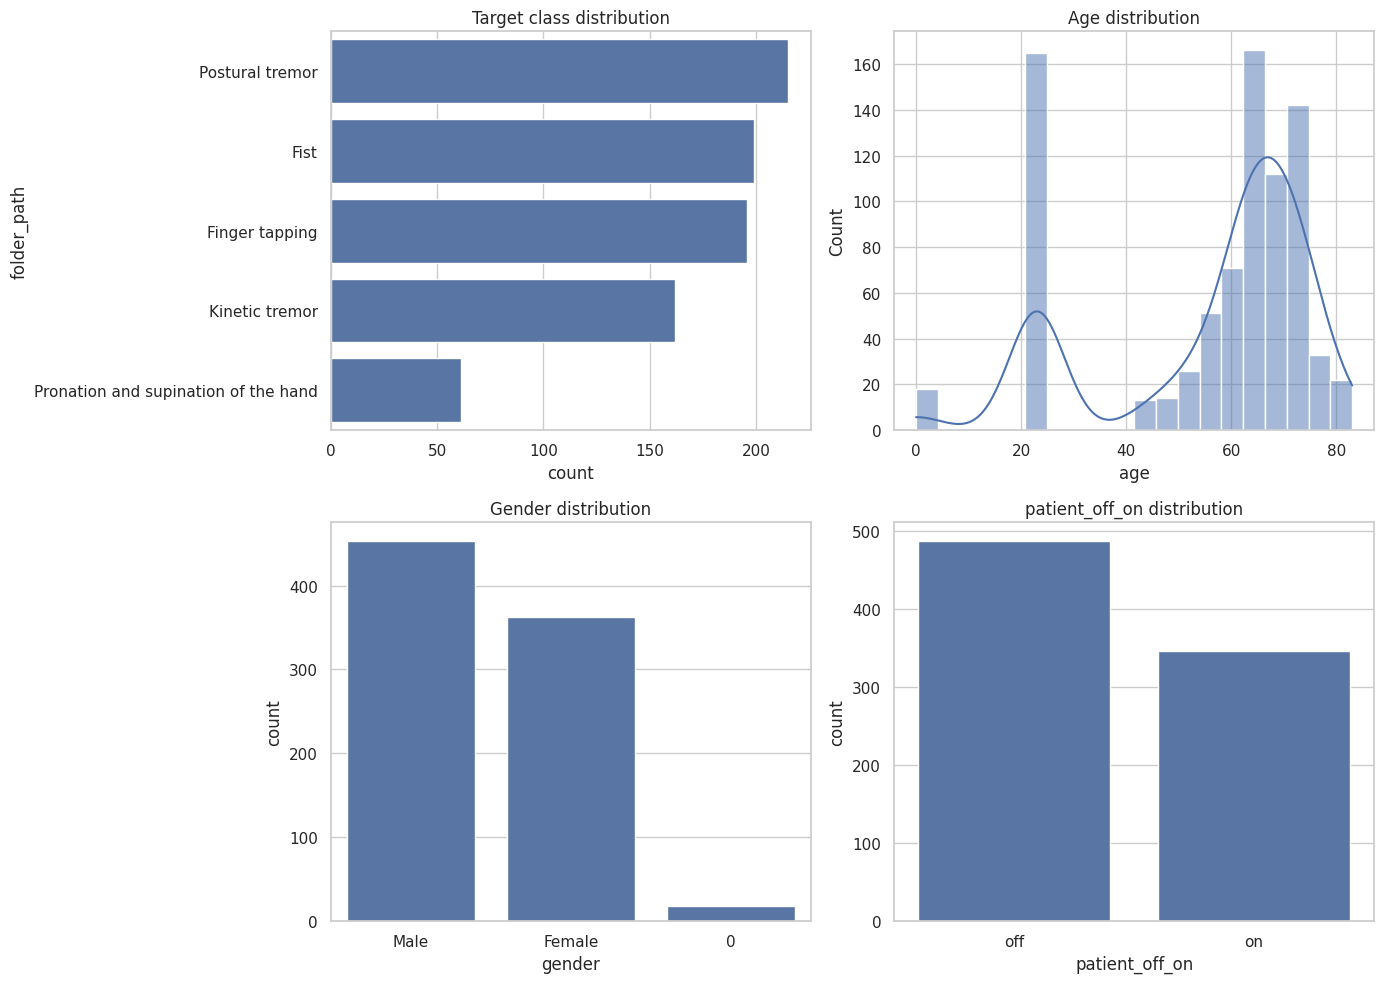

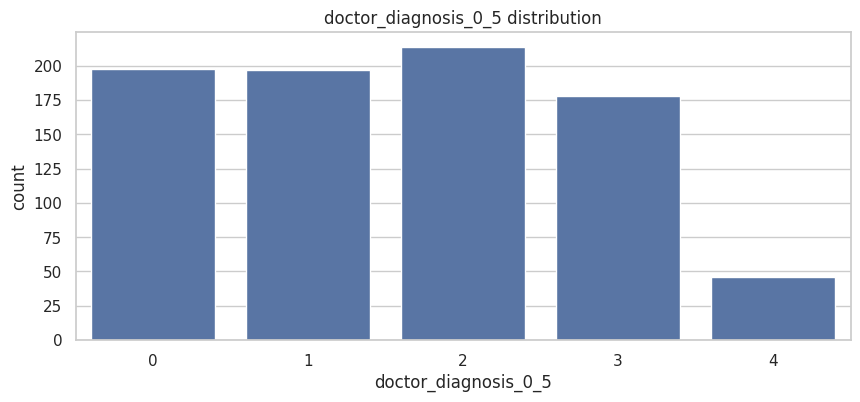

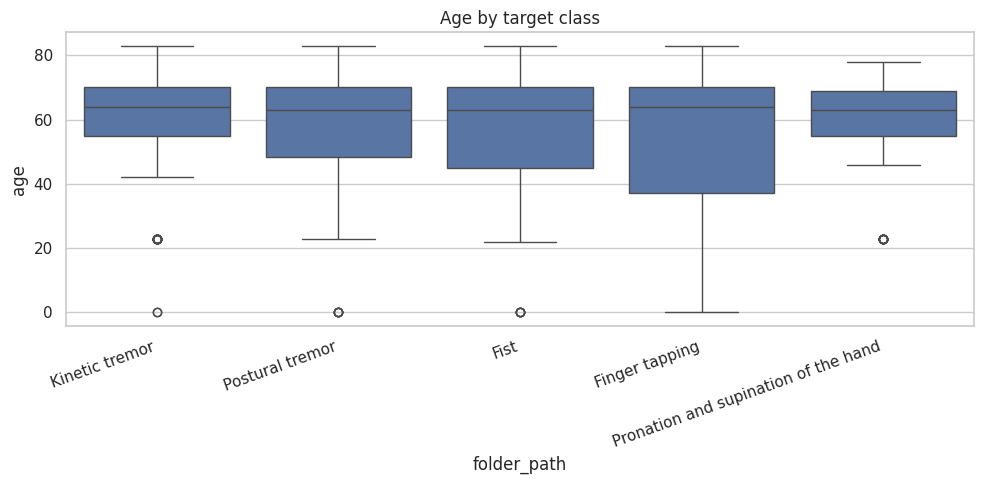

P(gender | class)


gender,0,Female,Male
folder_path,,,
Finger tapping,0.031,0.418,0.551
Fist,0.025,0.452,0.523
Kinetic tremor,0.012,0.420,0.568
Postural tremor,0.023,0.437,0.540
Pronation and supination of the hand,0.000,0.459,0.541


P(patient_off_on | class)


patient_off_on,off,on
folder_path,,
Finger tapping,0.597,0.403
Fist,0.583,0.417
Kinetic tremor,0.574,0.426
Postural tremor,0.581,0.419
Pronation and supination of the hand,0.590,0.410


P(doctor_diagnosis_0_5 | class)


doctor_diagnosis_0_5,0,1,2,3,4
folder_path,,,,,
Finger tapping,0.061,0.158,0.388,0.301,0.092
Fist,0.080,0.256,0.302,0.302,0.060
Kinetic tremor,0.537,0.259,0.123,0.074,0.006
Postural tremor,0.372,0.288,0.186,0.140,0.014
Pronation and supination of the hand,0.049,0.180,0.295,0.279,0.197


In [10]:


# Metadata EDA

# whether the target is imbalanced
# whether metadata is highly predictive or only mildly associated
# whether some classes occur in narrower age/severity ranges



fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=train, y="folder_path", order=train["folder_path"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Target class distribution")

sns.histplot(data=train, x="age", bins=20, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Age distribution")

sns.countplot(data=train, x="gender", order=train["gender"].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title("Gender distribution")

sns.countplot(data=train, x="patient_off_on", order=train["patient_off_on"].value_counts().index, ax=axes[1, 1])
axes[1, 1].set_title("patient_off_on distribution")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(data=train, x="doctor_diagnosis_0_5", order=sorted(train["doctor_diagnosis_0_5"].unique()))
plt.title("doctor_diagnosis_0_5 distribution")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x="folder_path", y="age")
plt.xticks(rotation=20, ha="right")
plt.title("Age by target class")
plt.tight_layout()
plt.show()

ct_gender = pd.crosstab(train["folder_path"], train["gender"], normalize="index").round(3)
ct_onoff = pd.crosstab(train["folder_path"], train["patient_off_on"], normalize="index").round(3)
ct_diag = pd.crosstab(train["folder_path"], train["doctor_diagnosis_0_5"], normalize="index").round(3)

print("P(gender | class)")
display(ct_gender)

print("P(patient_off_on | class)")
display(ct_onoff)

print("P(doctor_diagnosis_0_5 | class)")
display(ct_diag)

## The prediction target is moderately imbalanced

Your target distribution is:
Postural tremor: 215
Fist: 199
Finger tapping: 196
Kinetic tremor: 162
Pronation and supination of the hand: 61

So the minority class is clearly:

Pronation and supination of the hand at only 7.32%


Practically, accuracy alone will be misleading.

in multiclass medical ML with class imbalance, the model can look “good” while still performing badly on the rare class. So we should use:

macro F1
balanced accuracy
confusion matrix
per-class recall
not just overall accuracy.



## doctor_diagnosis_0_5 is not neutral

This is one of the most important finding in our EDA.
The diagnosis score distribution changes a lot by exercise class. For example:
 - Kinetic tremor has many score 0 cases
 - Pronation and supination of the hand has relatively more severe scores, including many score 4 cases
 - Finger tapping and Fist are concentrated more in 2–3

==>
doctor_diagnosis_0_5 may be predictive of the target.

==> Question:

Build an exercise-recognition model from movement, or partly a metadata-driven classifier? Or both?

metadata only
motion only
motion + metadata


## Age deserves special attention

In [11]:



# Inspect one raw recording


example_name = train.loc[0, "data_file_name"]
example_label = train.loc[0, "folder_path"]
example_path = os.path.join(RAW_DIR, example_name)

raw = pd.read_csv(example_path)

print("Example file:", example_name)
print("Example label:", example_label)
print("Raw shape:", raw.shape)

display(raw.head())
print("\nColumns:")
print(raw.columns.tolist())

print("\nMissing values in this raw file:")
display(raw.isna().sum().sort_values(ascending=False).head(20))

print("\nNumeric summary:")
display(raw.describe().T.head(15))

Example file: raw_data_d786d645-db38-11ec-b494-e82aea2c97f4.csv
Example label: Kinetic tremor
Raw shape: (324, 64)


,WRIST.x,WRIST.y,WRIST.z,THUMB_CMC.x,THUMB_CMC.y,THUMB_CMC.z,THUMB_MCP.x,THUMB_MCP.y,THUMB_MCP.z,THUMB_IP.x,THUMB_IP.y,THUMB_IP.z,THUMB_TIP.x,THUMB_TIP.y,THUMB_TIP.z,INDEX_FINGER_MCP.x,INDEX_FINGER_MCP.y,INDEX_FINGER_MCP.z,INDEX_FINGER_PIP.x,INDEX_FINGER_PIP.y,INDEX_FINGER_PIP.z,INDEX_FINGER_DIP.x,INDEX_FINGER_DIP.y,INDEX_FINGER_DIP.z,INDEX_FINGER_TIP.x,INDEX_FINGER_TIP.y,INDEX_FINGER_TIP.z,MIDDLE_FINGER_MCP.x,MIDDLE_FINGER_MCP.y,MIDDLE_FINGER_MCP.z,MIDDLE_FINGER_PIP.x,MIDDLE_FINGER_PIP.y,MIDDLE_FINGER_PIP.z,MIDDLE_FINGER_DIP.x,MIDDLE_FINGER_DIP.y,MIDDLE_FINGER_DIP.z,MIDDLE_FINGER_TIP.x,MIDDLE_FINGER_TIP.y,MIDDLE_FINGER_TIP.z,RING_FINGER_MCP.x,RING_FINGER_MCP.y,RING_FINGER_MCP.z,RING_FINGER_PIP.x,RING_FINGER_PIP.y,RING_FINGER_PIP.z,RING_FINGER_DIP.x,RING_FINGER_DIP.y,RING_FINGER_DIP.z,RING_FINGER_TIP.x,RING_FINGER_TIP.y,RING_FINGER_TIP.z,PINKY_MCP.x,PINKY_MCP.y,PINKY_MCP.z,PINKY_PIP.x,PINKY_PIP.y,PINKY_PIP.z,PINKY_DIP.x,PINKY_DIP.y,PINKY_DIP.z,PINKY_TIP.x,PINKY_TIP.y,PINKY_TIP.z,TIME
0,0.518580,0.418926,0.0,0.486112,0.431425,-0.012614,0.462542,0.443182,-0.033098,0.445827,0.464130,-0.049678,0.432222,0.472999,-0.065681,0.462482,0.385095,-0.067814,0.451120,0.424316,-0.098335,0.450283,0.448016,-0.111742,0.452373,0.462921,-0.118690,0.480929,0.383841,-0.072973,0.472169,0.443404,-0.109246,0.469300,0.489051,-0.115995,0.469953,0.525676,-0.118842,0.500975,0.394452,-0.076428,0.495695,0.456981,-0.109699,0.490711,0.500751,-0.110739,0.489329,0.531776,-0.107618,0.519942,0.412378,-0.079124,0.516582,0.464860,-0.104749,0.513424,0.498905,-0.108342,0.510988,0.519907,-0.108259,0.155905
1,0.524674,0.418294,0.0,0.492302,0.422500,-0.007173,0.462398,0.429668,-0.019414,0.440486,0.442321,-0.029922,0.421614,0.450319,-0.039522,0.464813,0.373373,-0.036897,0.449634,0.413674,-0.053992,0.445292,0.437376,-0.060464,0.441557,0.454661,-0.063586,0.481748,0.379700,-0.041841,0.467368,0.447313,-0.062469,0.461670,0.487496,-0.063392,0.457948,0.515082,-0.063094,0.500548,0.396900,-0.045953,0.487170,0.465191,-0.063182,0.479023,0.502490,-0.058074,0.473273,0.526773,-0.053245,0.517141,0.419765,-0.050309,0.507025,0.472829,-0.062204,0.501078,0.501878,-0.059324,0.496074,0.518486,-0.055968,0.197278
2,0.520091,0.405455,0.0,0.499369,0.388019,-0.002545,0.474279,0.391343,-0.011258,0.455972,0.411626,-0.019652,0.444078,0.433323,-0.027758,0.470743,0.377725,-0.030325,0.445778,0.410382,-0.044166,0.435755,0.436160,-0.048815,0.429376,0.457496,-0.050742,0.480723,0.391664,-0.035506,0.456028,0.446418,-0.050042,0.446085,0.481710,-0.050112,0.441509,0.507197,-0.049882,0.491972,0.412223,-0.039481,0.470468,0.465921,-0.051094,0.461375,0.496616,-0.047393,0.456420,0.518189,-0.044634,0.502869,0.435104,-0.043327,0.488093,0.477799,-0.051423,0.481339,0.501483,-0.048983,0.476914,0.519995,-0.046647,0.242097
3,0.461309,0.306356,0.0,0.455061,0.273995,0.003821,0.440599,0.245960,0.000997,0.426292,0.231943,-0.003374,0.414696,0.230963,-0.007004,0.436244,0.233516,-0.009332,0.407375,0.218977,-0.016444,0.402343,0.225248,-0.016825,0.404198,0.230565,-0.016311,0.435255,0.247290,-0.015770,0.400311,0.249144,-0.022460,0.402740,0.263694,-0.018934,0.411578,0.269796,-0.015964,0.433852,0.267140,-0.021864,0.403950,0.279065,-0.026641,0.408218,0.290976,-0.021861,0.417081,0.292903,-0.018552,0.433119,0.289460,-0.027802,0.409829,0.303390,-0.030585,0.409881,0.312131,-0.028002,0.414817,0.315095,-0.025832,0.653949
4,0.468104,0.313761,0.0,0.463882,0.276673,0.006458,0.450494,0.246644,0.004609,0.435121,0.234613,0.000743,0.423950,0.232512,-0.002019,0.440626,0.225620,-0.002573,0.410644,0.230683,-0.006521,0.412139,0.248147,-0.006136,0.419197,0.253690,-0.005583,0.434019,0.243602,-0.009930,0.407125,0.256698,-0.011141,0.412310,0.272249,-0.007701,0.421676,0.275162,-0.006251,0.428824,0.266899,-0.016918,0.406309,0.280137,-0.016927,0.412923,0.293454,-0.012565,0.422750,0.294849,-0.011063,0.425346,0.292538,-0.023654,0.409268,0.305751,-0.023050,0.415695,0.316684,-0.019751,0.424411,0.318238,-0.018088,0.701525



Columns:
['WRIST.x', 'WRIST.y', 'WRIST.z', 'THUMB_CMC.x', 'THUMB_CMC.y', 'THUMB_CMC.z', 'THUMB_MCP.x', 'THUMB_MCP.y', 'THUMB_MCP.z', 'THUMB_IP.x', 'THUMB_IP.y', 'THUMB_IP.z', 'THUMB_TIP.x', 'THUMB_TIP.y', 'THUMB_TIP.z', 'INDEX_FINGER_MCP.x', 'INDEX_FINGER_MCP.y', 'INDEX_FINGER_MCP.z', 'INDEX_FINGER_PIP.x', 'INDEX_FINGER_PIP.y', 'INDEX_FINGER_PIP.z', 'INDEX_FINGER_DIP.x', 'INDEX_FINGER_DIP.y', 'INDEX_FINGER_DIP.z', 'INDEX_FINGER_TIP.x', 'INDEX_FINGER_TIP.y', 'INDEX_FINGER_TIP.z', 'MIDDLE_FINGER_MCP.x', 'MIDDLE_FINGER_MCP.y', 'MIDDLE_FINGER_MCP.z', 'MIDDLE_FINGER_PIP.x', 'MIDDLE_FINGER_PIP.y', 'MIDDLE_FINGER_PIP.z', 'MIDDLE_FINGER_DIP.x', 'MIDDLE_FINGER_DIP.y', 'MIDDLE_FINGER_DIP.z', 'MIDDLE_FINGER_TIP.x', 'MIDDLE_FINGER_TIP.y', 'MIDDLE_FINGER_TIP.z', 'RING_FINGER_MCP.x', 'RING_FINGER_MCP.y', 'RING_FINGER_MCP.z', 'RING_FINGER_PIP.x', 'RING_FINGER_PIP.y', 'RING_FINGER_PIP.z', 'RING_FINGER_DIP.x', 'RING_FINGER_DIP.y', 'RING_FINGER_DIP.z', 'RING_FINGER_TIP.x', 'RING_FINGER_TIP.y', 'RING_FI

,0
WRIST.x,0
WRIST.y,0
WRIST.z,0
THUMB_CMC.x,0
THUMB_CMC.y,0
THUMB_CMC.z,0
THUMB_MCP.x,0
THUMB_MCP.y,0
THUMB_MCP.z,0
THUMB_IP.x,0



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
WRIST.x,324.0,0.474426,0.013719,0.416068,0.467406,0.471638,0.477482,0.524674
WRIST.y,324.0,0.356521,0.028278,0.306356,0.333762,0.350837,0.373744,0.444331
WRIST.z,324.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
THUMB_CMC.x,324.0,0.457477,0.015423,0.416855,0.447360,0.459190,0.467527,0.499950
THUMB_CMC.y,324.0,0.332979,0.044053,0.273995,0.293481,0.327852,0.360067,0.455445
THUMB_CMC.z,324.0,0.001877,0.008016,-0.020692,-0.001714,0.004717,0.007884,0.011560
THUMB_MCP.x,324.0,0.439616,0.017573,0.399269,0.425934,0.441854,0.453146,0.494672
THUMB_MCP.y,324.0,0.315740,0.058313,0.243794,0.261551,0.307696,0.352296,0.471923
THUMB_MCP.z,324.0,-0.003887,0.014122,-0.046742,-0.010975,0.001294,0.007002,0.012412
THUMB_IP.x,324.0,0.424444,0.018362,0.386145,0.409094,0.425819,0.436985,0.492230


In [12]:



# hand-landmark structure

coord_cols = [c for c in raw.columns if c != "TIME"]
base_names = sorted(set(c.rsplit(".", 1)[0] for c in coord_cols))
axes = sorted(set(c.rsplit(".", 1)[1] for c in coord_cols))

print("Number of coordinate columns:", len(coord_cols))
print("Landmark count:", len(base_names))
print("Axes:", axes)
print("\nLandmarks:")
print(base_names)

Number of coordinate columns: 63
Landmark count: 21
Axes: ['x', 'y', 'z']

Landmarks:
['INDEX_FINGER_DIP', 'INDEX_FINGER_MCP', 'INDEX_FINGER_PIP', 'INDEX_FINGER_TIP', 'MIDDLE_FINGER_DIP', 'MIDDLE_FINGER_MCP', 'MIDDLE_FINGER_PIP', 'MIDDLE_FINGER_TIP', 'PINKY_DIP', 'PINKY_MCP', 'PINKY_PIP', 'PINKY_TIP', 'RING_FINGER_DIP', 'RING_FINGER_MCP', 'RING_FINGER_PIP', 'RING_FINGER_TIP', 'THUMB_CMC', 'THUMB_IP', 'THUMB_MCP', 'THUMB_TIP', 'WRIST']


# EDA 2

In [13]:



# Inspect suspicious metadata values: Age 0 & 23

"""
Is age 0 really an “unknown” category/ missing data?
Is age 23 suspiciously concentrated in certain classes?
"""

print("Age counts (sorted):")
display(train["age"].value_counts().sort_index())

print("How many age == 0?")
print((train["age"] == 0).sum())

print("\nHow many age == 23?")
print((train["age"] == 23).sum())

print("\nRows with age == 0:")
display(train.loc[train["age"] == 0].sort_values(["folder_path", "doctor_diagnosis_0_5"]))

print("\nClass distribution among age == 23:")
display(train.loc[train["age"] == 23, "folder_path"].value_counts())
display((train.loc[train["age"] == 23, "folder_path"].value_counts(normalize=True) * 100).round(2))

print("\nGender == '0' rows:")
display(train.loc[train["gender"] == "0"].sort_values(["folder_path", "age"]))

print("\nCrosstab: age_is_zero vs class")
train["age_is_zero"] = (train["age"] == 0).astype(int)
display(pd.crosstab(train["folder_path"], train["age_is_zero"], normalize="index").round(3))

Age counts (sorted):


,count
age,
0,18
22,2
23,163
42,3
44,10
46,5
47,9
50,9
51,10


How many age == 0?
18

How many age == 23?
163

Rows with age == 0:


,data_file_name,folder_path,gender,age,patient_off_on,doctor_diagnosis_0_5
71,raw_data_dfb2e683-2549-11ed-964f-88a4c211973d.csv,Finger tapping,0,0,on,0
107,raw_data_18ea0edb-29db-11ed-b229-88a4c211973d.csv,Finger tapping,0,0,on,0
196,raw_data_a7ecf8d7-29df-11ed-a234-88a4c211973d.csv,Finger tapping,0,0,on,0
672,raw_data_20595efb-29de-11ed-b4ce-88a4c211973d.csv,Finger tapping,0,0,on,0
532,raw_data_d367344b-90c3-11ed-917e-e82aea2c97f4.csv,Finger tapping,0,0,off,2
412,raw_data_738827cb-3a62-11ed-af91-b469216ca443.csv,Finger tapping,0,0,off,4
177,raw_data_f7aaab5b-08c0-11ed-8ea5-b469216ca443.csv,Fist,0,0,on,1
343,raw_data_87b4b553-246f-11ed-9e32-e82aea2c97f4.csv,Fist,0,0,on,1
620,raw_data_ee2fc685-90c3-11ed-aaaa-e82aea2c97f4.csv,Fist,0,0,off,1
754,raw_data_7786b21d-08c1-11ed-8dcf-b469216ca443.csv,Fist,0,0,on,1



Class distribution among age == 23:


...

,proportion
folder_path,
Finger tapping,25.77
Fist,25.15
Postural tremor,25.15
Kinetic tremor,15.95
Pronation and supination of the hand,7.98



Gender == '0' rows:


,data_file_name,folder_path,gender,age,patient_off_on,doctor_diagnosis_0_5
71,raw_data_dfb2e683-2549-11ed-964f-88a4c211973d.csv,Finger tapping,0,0,on,0
107,raw_data_18ea0edb-29db-11ed-b229-88a4c211973d.csv,Finger tapping,0,0,on,0
196,raw_data_a7ecf8d7-29df-11ed-a234-88a4c211973d.csv,Finger tapping,0,0,on,0
412,raw_data_738827cb-3a62-11ed-af91-b469216ca443.csv,Finger tapping,0,0,off,4
532,raw_data_d367344b-90c3-11ed-917e-e82aea2c97f4.csv,Finger tapping,0,0,off,2
672,raw_data_20595efb-29de-11ed-b4ce-88a4c211973d.csv,Finger tapping,0,0,on,0
177,raw_data_f7aaab5b-08c0-11ed-8ea5-b469216ca443.csv,Fist,0,0,on,1
343,raw_data_87b4b553-246f-11ed-9e32-e82aea2c97f4.csv,Fist,0,0,on,1
620,raw_data_ee2fc685-90c3-11ed-aaaa-e82aea2c97f4.csv,Fist,0,0,off,1
754,raw_data_7786b21d-08c1-11ed-8dcf-b469216ca443.csv,Fist,0,0,on,1



Crosstab: age_is_zero vs class


age_is_zero,0,1
folder_path,,
Finger tapping,0.969,0.031
Fist,0.975,0.025
Kinetic tremor,0.988,0.012
Postural tremor,0.977,0.023
Pronation and supination of the hand,1.000,0.000


In [14]:




# Compare train vs test metadata distributions
"""
If test metadata distribution is very different from train, model performance can drop for distribution-shift reasons rather than because the model is intrinsically bad.
"""

def compare_cat(train_df, test_df, col):
    out = pd.concat(
        [
            train_df[col].value_counts(normalize=True).rename("train_prop"),
            test_df[col].value_counts(normalize=True).rename("test_prop"),
        ],
        axis=1
    ).fillna(0)
    out["diff"] = out["test_prop"] - out["train_prop"]
    return out.sort_index()

print("Gender train vs test")
display(compare_cat(train, test, "gender"))

print("patient_off_on train vs test")
display(compare_cat(train, test, "patient_off_on"))

print("doctor_diagnosis_0_5 train vs test")
display(compare_cat(train, test, "doctor_diagnosis_0_5"))

print("Age summary train")
display(train["age"].describe())

print("Age summary test")
display(test["age"].describe())


Gender train vs test


,train_prop,test_prop,diff
gender,,,
0,0.021609,0.019608,-0.002001
Female,0.434574,0.431373,-0.003201
Male,0.543818,0.549020,0.005202


patient_off_on train vs test


,train_prop,test_prop,diff
patient_off_on,,,
off,0.584634,0.591036,0.006403
on,0.415366,0.408964,-0.006403


doctor_diagnosis_0_5 train vs test


,train_prop,test_prop,diff
doctor_diagnosis_0_5,,,
0,0.237695,0.257703,0.020008
1,0.236495,0.224090,-0.012405
2,0.256903,0.263305,0.006403
3,0.213685,0.207283,-0.006403
4,0.055222,0.047619,-0.007603


Age summary train


,age
count,833.000000
mean,55.819928
std,20.193743
min,0.000000
25%,47.000000
50%,64.000000
75%,70.000000
max,83.000000


Age summary test


,age
count,357.000000
mean,54.616246
std,20.326301
min,0.000000
25%,44.000000
50%,63.000000
75%,70.000000
max,83.000000


In [15]:



# Global raw-file summary
'''
the raw data is consistently structured across the whole dataset, not just in one example.
'''



from tqdm.auto import tqdm
import os
import numpy as np
import pandas as pd

indexed_names = sorted(set(train["data_file_name"]) | set(test["data_file_name"]))

def summarize_raw_file(file_name):
    path = os.path.join(RAW_DIR, file_name)
    df = pd.read_csv(path)

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    signal_cols = [c for c in numeric_cols if c != "TIME"]

    time = df["TIME"].to_numpy()
    dt = np.diff(time)

    return {
        "data_file_name": file_name,
        "n_rows": df.shape[0],
        "n_cols": df.shape[1],
        "n_signal_cols": len(signal_cols),
        "n_missing_total": int(df.isna().sum().sum()),
        "time_start": float(time[0]) if len(time) else np.nan,
        "time_end": float(time[-1]) if len(time) else np.nan,
        "duration": float(time[-1] - time[0]) if len(time) > 1 else np.nan,
        "mean_dt": float(dt.mean()) if len(dt) else np.nan,
        "median_dt": float(np.median(dt)) if len(dt) else np.nan,
        "fps_est": float(1.0 / dt.mean()) if len(dt) and dt.mean() > 0 else np.nan,
        "time_strictly_increasing": bool(np.all(dt > 0)) if len(dt) else False,
        "const_signal_cols_count": int(sum(df[c].nunique(dropna=False) == 1 for c in signal_cols)),
        "schema_signature": "|".join(df.columns),
    }

raw_summary = pd.DataFrame(
    [summarize_raw_file(name) for name in tqdm(indexed_names)]
)

print("raw_summary shape:", raw_summary.shape)
display(raw_summary.head())

print("\nSummary stats:")
display(raw_summary.drop(columns=["data_file_name", "schema_signature"]).describe().T)

print("\nUnique schema signatures:", raw_summary["schema_signature"].nunique())
print("Files with n_cols != 64:", (raw_summary["n_cols"] != 64).sum())
print("Files with n_signal_cols != 63:", (raw_summary["n_signal_cols"] != 63).sum())
print("Files with missing values:", (raw_summary["n_missing_total"] > 0).sum())
print("Files with non-increasing TIME:", (~raw_summary["time_strictly_increasing"]).sum())

  0%|          | 0/1190 [00:00<?, ?it/s]

raw_summary shape: (1190, 14)


,data_file_name,n_rows,n_cols,n_signal_cols,n_missing_total,time_start,time_end,duration,mean_dt,median_dt,fps_est,time_strictly_increasing,const_signal_cols_count,schema_signature
0,raw_data_001cd271-1de8-11ed-9476-b469216ca443.csv,369,64,63,0,1.042052,21.569182,20.527130,0.055780,0.053691,17.927494,True,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
1,raw_data_001d11b5-c541-11ec-a570-e82aea2c97f4.csv,423,64,63,0,0.231269,20.908572,20.677303,0.048998,0.049665,20.408851,True,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
2,raw_data_009ed99d-0361-11ed-9602-e82aea2c97f4.csv,206,64,63,0,0.215611,10.291739,10.076128,0.049152,0.049066,20.345116,True,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
3,raw_data_01199504-c171-11ec-bb5a-e82aea2c97f4.csv,342,64,63,0,0.108654,19.067678,18.959024,0.055598,0.048205,17.986158,True,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
4,raw_data_023f6d37-0caf-11ed-be25-b469216ca443.csv,485,64,63,0,0.380352,20.664152,20.283800,0.041909,0.040918,23.861406,True,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....



Summary stats:


,count,mean,std,min,25%,50%,75%,max
n_rows,1190.0,393.887395,120.532380,100.000000,326.250000,390.500000,462.500000,988.000000
n_cols,1190.0,64.000000,0.000000,64.000000,64.000000,64.000000,64.000000,64.000000
n_signal_cols,1190.0,63.000000,0.000000,63.000000,63.000000,63.000000,63.000000,63.000000
n_missing_total,1190.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
time_start,1190.0,0.548376,0.825063,0.022370,0.159244,0.308599,0.578546,10.477351
time_end,1190.0,19.261876,3.019462,2.642787,19.614740,20.459058,20.830420,21.617283
duration,1190.0,18.713500,3.086983,2.376303,18.583584,19.920172,20.514306,21.037018
mean_dt,1190.0,0.051498,0.017539,0.010632,0.041244,0.049381,0.054258,0.192705
median_dt,1190.0,0.046085,0.008624,0.029057,0.039581,0.048439,0.052255,0.095314
fps_est,1190.0,21.100499,5.931448,5.189280,18.430433,20.250562,24.246101,94.056638



Unique schema signatures: 1
Files with n_cols != 64: 0
Files with n_signal_cols != 63: 0
Files with missing values: 0
Files with non-increasing TIME: 43


In [16]:



# Which columns are constant across files?

'''
If a column is constant in nearly every file, it is not informative.
For example, WRIST.z may be acting as a reference anchor.
'''


from collections import Counter

def get_const_cols(file_name):
    path = os.path.join(RAW_DIR, file_name)
    df = pd.read_csv(path)
    signal_cols = [c for c in df.select_dtypes(include=np.number).columns if c != "TIME"]
    return [c for c in signal_cols if df[c].nunique(dropna=False) == 1]

const_counter = Counter()
for name in tqdm(indexed_names):
    const_counter.update(get_const_cols(name))

const_df = (
    pd.DataFrame(const_counter.items(), columns=["column", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(const_df.head(30))

  0%|          | 0/1190 [00:00<?, ?it/s]

,column,count
0,WRIST.z,1190


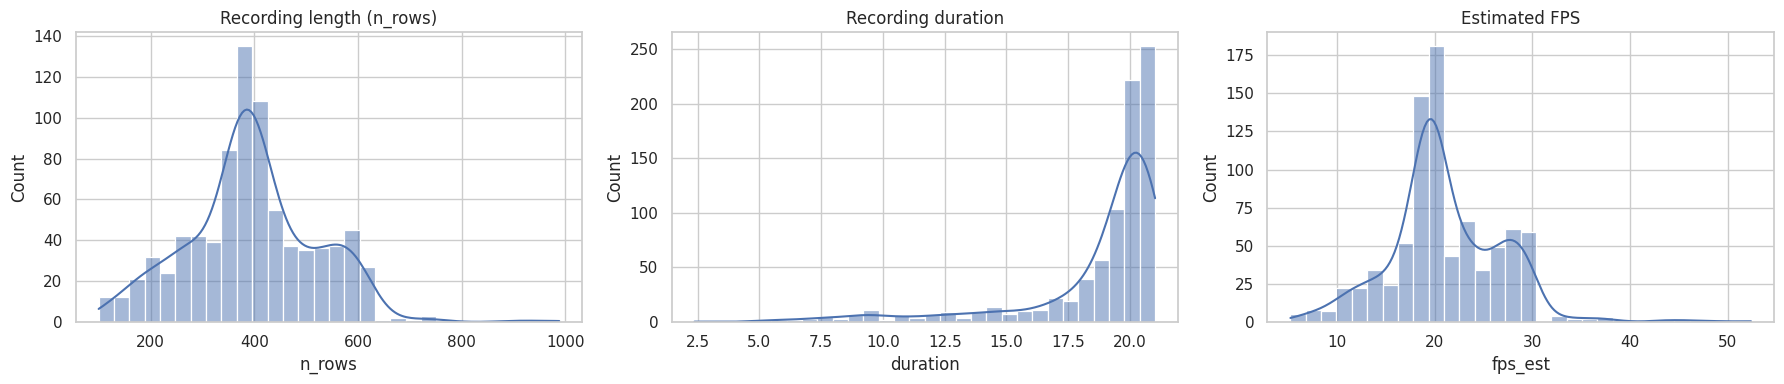

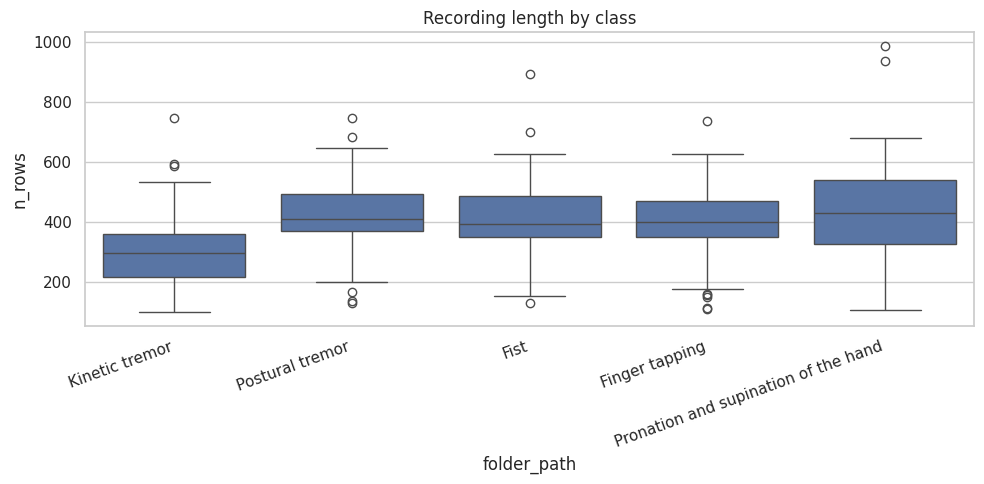

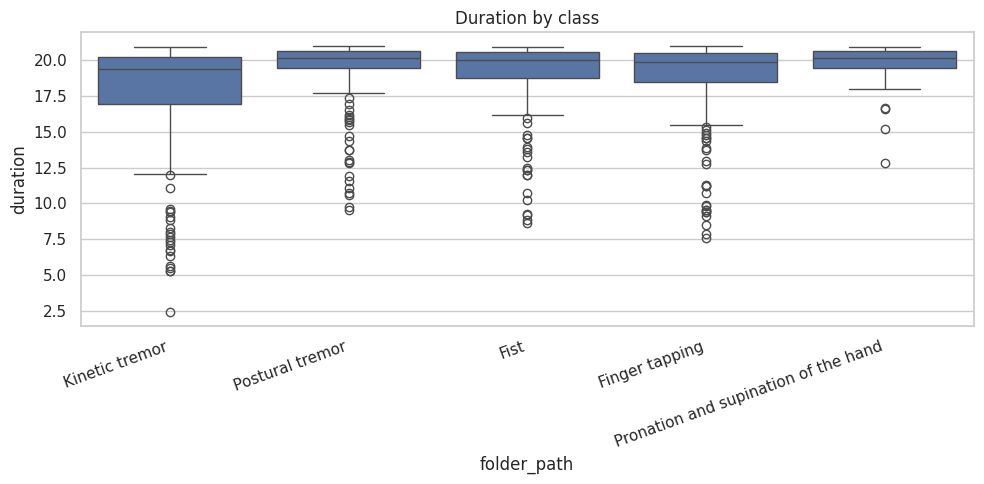

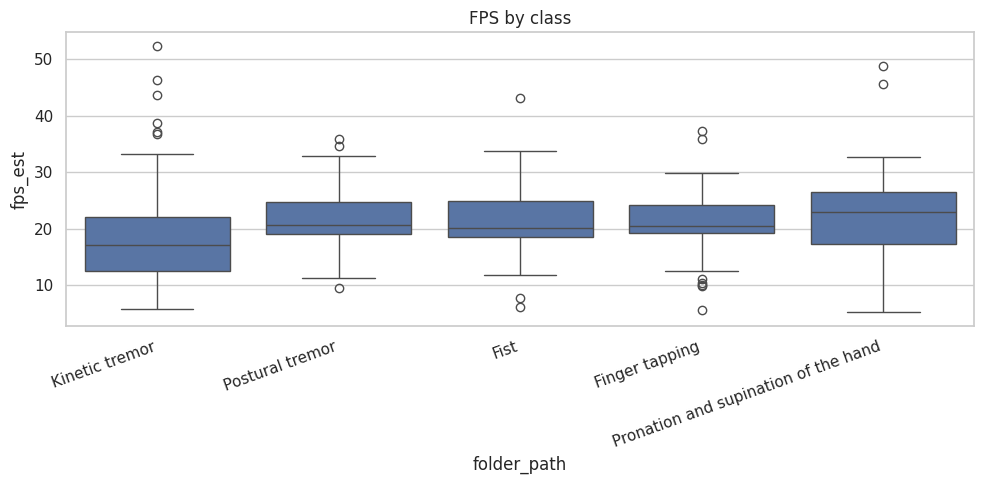

n_rows                         duration                                    fps_est                                const_signal_cols_count             
                                            mean         std  min  max       mean       std        min        max       mean       std       min        max                    mean  std min max
folder_path                                                                                                                                                                                     
Finger tapping                        407.933673  115.393244  111  737  18.667324  3.041828   7.607708  21.013875  21.706622  4.671815  5.665674  37.256675                     1.0  0.0   1   1
Fist                                  409.035176  116.187561  131  895  18.991139  2.566997   8.612028  20.933441  21.382377  4.845814  6.240432  43.212613                     1.0  0.0   1   1
Kinetic tremor                        300.518519  110.375881  100  748  17.385355  4.400086   2.376303  20.908634  18.361700  7.908873  5.759535  52.401626                     1.0  0.0   1   1
Postural tremor                       430.409302  106.240425  131  748  19.460507  2.225755   9.507445  20.975768  21.935367  4.328038  9.475879  35.873676                     1.0  0.0   1   1
Pronation and supination of the hand  439.983607  158.874950  109  988  19.684435  1.518546  12.832553  20.911241  22.212010  7.519886  5.189280  48.817530                     1.0  0.0   1   1

In [17]:



#Sequence length, duration, and FPS by class
'''
If one class systematically has longer recordings, then sequence length itself may act as a hidden label cue.

That is not automatically leakage, but it is protocol information rather than pure motor physiology.
'''

train_eda = train.merge(raw_summary, on="data_file_name", how="left")
test_eda = test.merge(raw_summary, on="data_file_name", how="left")

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(train_eda["n_rows"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recording length (n_rows)")

sns.histplot(train_eda["duration"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Recording duration")

sns.histplot(train_eda["fps_est"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Estimated FPS")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=train_eda, x="folder_path", y="n_rows")
plt.xticks(rotation=20, ha="right")
plt.title("Recording length by class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=train_eda, x="folder_path", y="duration")
plt.xticks(rotation=20, ha="right")
plt.title("Duration by class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=train_eda, x="folder_path", y="fps_est")
plt.xticks(rotation=20, ha="right")
plt.title("FPS by class")
plt.tight_layout()
plt.show()

display(
    train_eda.groupby("folder_path")[["n_rows", "duration", "fps_est", "const_signal_cols_count"]]
    .agg(["mean", "std", "min", "max"])
)

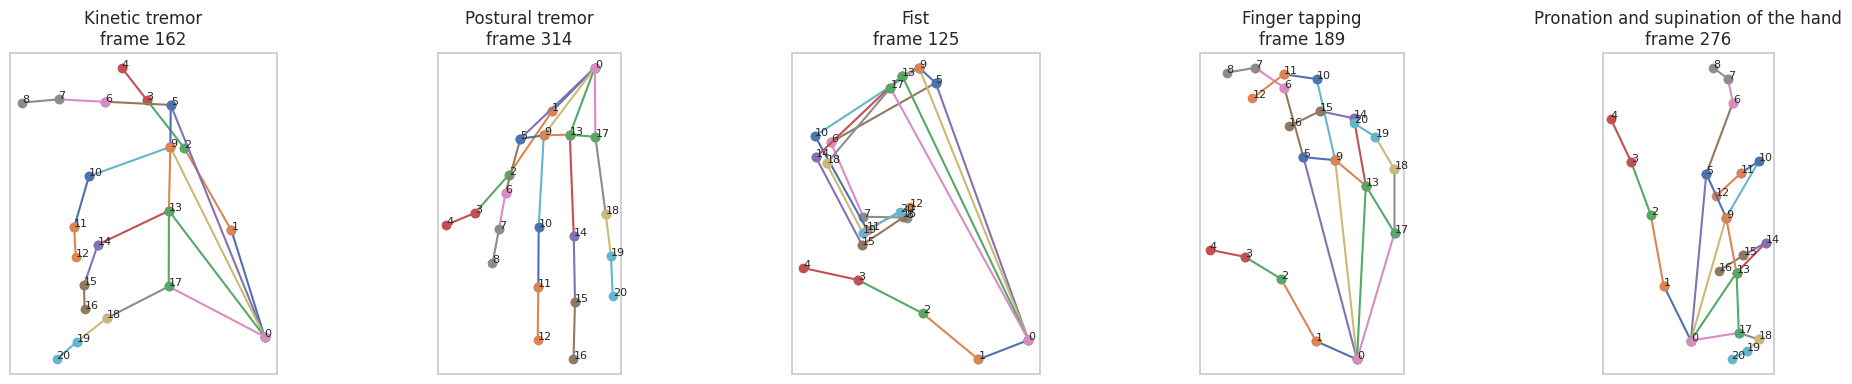

In [18]:



# Visualize one example from each class as a hand skeleton


LANDMARKS = [
    "WRIST",
    "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
    "INDEX_FINGER_MCP", "INDEX_FINGER_PIP", "INDEX_FINGER_DIP", "INDEX_FINGER_TIP",
    "MIDDLE_FINGER_MCP", "MIDDLE_FINGER_PIP", "MIDDLE_FINGER_DIP", "MIDDLE_FINGER_TIP",
    "RING_FINGER_MCP", "RING_FINGER_PIP", "RING_FINGER_DIP", "RING_FINGER_TIP",
    "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP"
]

CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]

def plot_hand_frame(ax, df, frame_idx, title):
    row = df.iloc[frame_idx]
    xs = [row[f"{lm}.x"] for lm in LANDMARKS]
    ys = [row[f"{lm}.y"] for lm in LANDMARKS]

    for a, b in CONNECTIONS:
        ax.plot([xs[a], xs[b]], [ys[a], ys[b]], marker="o")
    for i, (x, y) in enumerate(zip(xs, ys)):
        ax.text(x, y, str(i), fontsize=8)

    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

classes = train["folder_path"].unique().tolist()
fig, axes = plt.subplots(1, len(classes), figsize=(20, 4))

for ax, cls in zip(axes, classes):
    fname = train.loc[train["folder_path"] == cls, "data_file_name"].iloc[0]
    df = pd.read_csv(os.path.join(RAW_DIR, fname))
    frame_idx = len(df) // 2
    plot_hand_frame(ax, df, frame_idx, f"{cls}\nframe {frame_idx}")

plt.tight_layout()
plt.show()

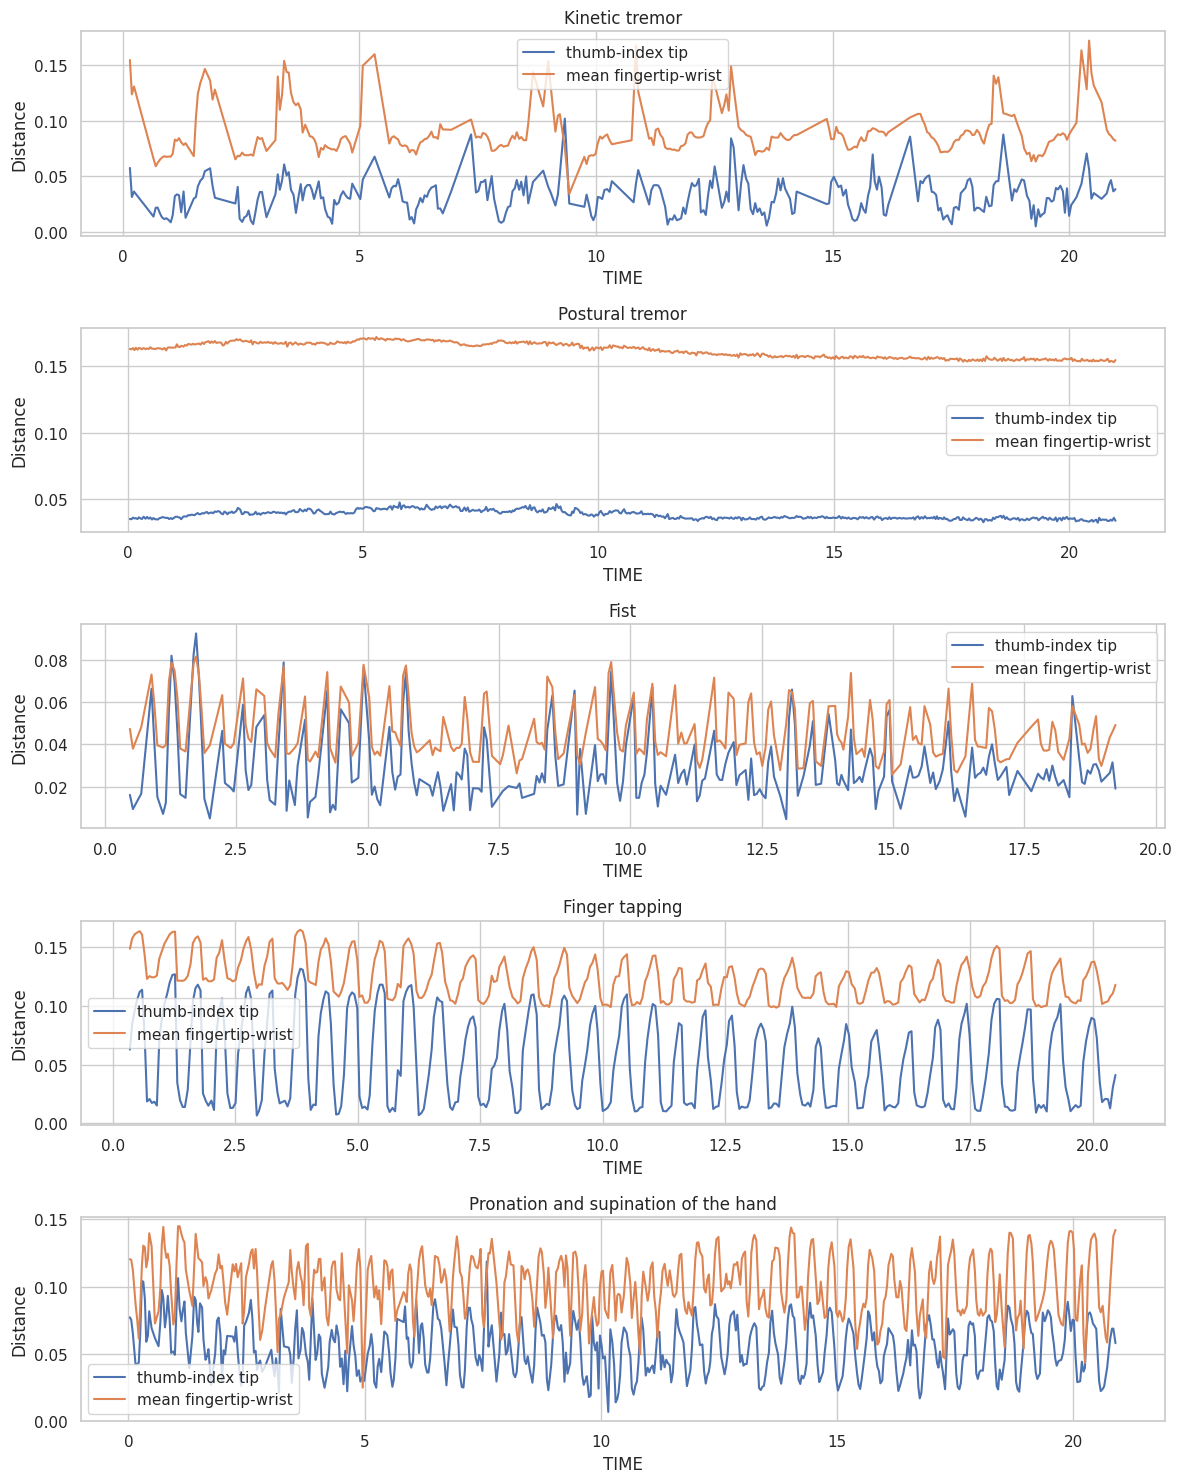

In [19]:

# Derived distances that are clinically meaningful
'''
Distances are more anatomical than raw coordinates.

For example:

fist should often reduce fingertip-to-wrist distances

finger tapping may create rhythmic thumb-finger distance changes

postural tremor may show oscillation around a stable mean posture
'''


def dist3(df, a, b):
    return np.sqrt(
        (df[f"{a}.x"] - df[f"{b}.x"])**2 +
        (df[f"{a}.y"] - df[f"{b}.y"])**2 +
        (df[f"{a}.z"] - df[f"{b}.z"])**2
    )

def add_basic_distances(df):
    out = df.copy()
    out["thumb_index_tip_dist"] = dist3(out, "THUMB_TIP", "INDEX_FINGER_TIP")
    out["thumb_middle_tip_dist"] = dist3(out, "THUMB_TIP", "MIDDLE_FINGER_TIP")
    out["index_tip_wrist_dist"] = dist3(out, "INDEX_FINGER_TIP", "WRIST")
    out["middle_tip_wrist_dist"] = dist3(out, "MIDDLE_FINGER_TIP", "WRIST")
    out["ring_tip_wrist_dist"] = dist3(out, "RING_FINGER_TIP", "WRIST")
    out["pinky_tip_wrist_dist"] = dist3(out, "PINKY_TIP", "WRIST")
    out["mean_fingertip_wrist_dist"] = out[
        ["index_tip_wrist_dist", "middle_tip_wrist_dist", "ring_tip_wrist_dist", "pinky_tip_wrist_dist"]
    ].mean(axis=1)
    return out

classes = train["folder_path"].unique().tolist()
fig, axes = plt.subplots(len(classes), 1, figsize=(12, 3 * len(classes)), sharex=False)

if len(classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    fname = train.loc[train["folder_path"] == cls, "data_file_name"].iloc[0]
    df = pd.read_csv(os.path.join(RAW_DIR, fname))
    df = add_basic_distances(df)

    ax.plot(df["TIME"], df["thumb_index_tip_dist"], label="thumb-index tip")
    ax.plot(df["TIME"], df["mean_fingertip_wrist_dist"], label="mean fingertip-wrist")
    ax.set_title(cls)
    ax.set_xlabel("TIME")
    ax.set_ylabel("Distance")
    ax.legend()

plt.tight_layout()
plt.show()

### The raw recordings are anatomically and behaviorally meaningful
very good, visually well skeleton plots and distance plots

These figures are the strongest evidence showing that the raw recordings are anatomically and behaviorally meaningful.

#### Postural tremor
The derived distances are comparatively stable over time.

    thumb-index tip distance is almost flat

    mean fingertip-wrist distance is also quite stable

Interpretation: the hand is being held in a posture, so the overall geometry is maintained. Small oscillations may still exist, but the dominant behavior is “maintain position.”

#### Finger tapping

This is the clearest one.

    strong rhythmic oscillation in thumb-index tip distance

    repeated periodic pattern

Interpretation: exactly what we would expect clinically. Finger tapping should create repeated opening-closing contact-like motion between thumb and index or nearby fingers.

#### Fist

Also rhythmic, but with a different geometry.

    repetitive oscillations

    lower overall hand-opening profile than postural tremor

    opening/closing behavior appears more global than just thumb-index

Interpretation: fist-related movement should change multiple fingertip-to-wrist distances together, not just one local pair.

Pronation and supination of the hand

The pattern is periodic, but the distances are less class-defining than in finger tapping.

Interpretation: this is important. Pronation/supination is primarily a rotation/orientation task, not just an opening/closing task. Distances alone may miss a lot of the discriminative signal.

#### Kinetic tremor

More irregular and less cleanly periodic.

Interpretation: that also makes sense. Kinetic tremor happens during voluntary motion, so the signal is a mix of intended movement plus tremor-related oscillation.

Why this matters

Immediate meaning: the dataset does contain meaningful movement signal.

Deeper meaning: your future model should not rely only on generic statistics of raw coordinates. It should include features that match the actual biomechanics of each exercise:

    distances for opening/closing tasks

    orientation features for pronation/supination

    rhythmic features for tapping

    variability features for tremor-related motion

This is the kind of reasoning that makes a medical ML project stronger.

In [20]:


# Metadata-only sanity baseline

# This is not the final model. It is a diagnostic test.
'''
Scientific question:

How much of the target can be predicted without looking at motion at all?
If metadata-only performance is high enough.
'''


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

meta_df = train[["gender", "age", "patient_off_on", "doctor_diagnosis_0_5"]].copy()
meta_df["age_is_zero"] = (meta_df["age"] == 0).astype(int)

X_meta = meta_df
y = train["folder_path"].copy()

cat_cols = ["gender", "patient_off_on"]
num_cols = ["age", "doctor_diagnosis_0_5", "age_is_zero"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

models = {
    "Dummy": Pipeline([
        ("prep", preprocess),
        ("clf", DummyClassifier(strategy="most_frequent"))
    ]),
    "LogReg": Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=3000))
    ]),
    "RF": Pipeline([
        ("prep", preprocess),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "macro_f1": "f1_macro"}

rows = []
for name, model in models.items():
    scores = cross_validate(model, X_meta, y, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        "model": name,
        "acc_mean": scores["test_accuracy"].mean(),
        "acc_std": scores["test_accuracy"].std(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
    })

meta_results = pd.DataFrame(rows).sort_values("macro_f1_mean", ascending=False)
display(meta_results)

,model,acc_mean,acc_std,macro_f1_mean,macro_f1_std
1,LogReg,0.324118,0.019902,0.260911,0.028207
2,RF,0.271279,0.036619,0.234185,0.040083
0,Dummy,0.258105,0.000760,0.082062,0.000192


1. The metadata-only baseline gave:

- Dummy: accuracy 0.258, macro-F1 0.082

- Logistic regression: accuracy 0.324, macro-F1 0.261

- Random forest: accuracy 0.271, macro-F1 0.234

=>

- Metadata alone is not trivial, but it is also not sufficient.

- It beats dummy, especially in macro-F1

2. doctor_diagnosis_0_5 is a real confounder / auxiliary predictor (variable that helps predict the target even though ut us )

This variable is a score given by a doctor describing how severe the Parkinson’s symptoms are.

Example scale:

Score	Meaning
0	no symptoms
1–2	mild symptoms
3–4	moderate
5	severe

Clinical metadata, particularly physician-rated motor severity, carries non-negligible predictive information for exercise classification and should therefore be treated as an auxiliary signal rather than ignored.

In [21]:
# 1. Inspect files with an unusually high number of frames
print("--- Top 10 longest recordings (by n_rows) ---")
display(raw_summary.sort_values("n_rows", ascending=False).head(10))

# 2. Filter and inspect the files with non-increasing time
non_inc_df = raw_summary[~raw_summary["time_strictly_increasing"]].copy()
print(f"\n--- Total files with non-increasing time: {len(non_inc_df)} ---")
display(non_inc_df[["data_file_name", "n_rows", "duration", "fps_est"]].head(10))

# 3. Deep dive into the first problematic file to see the exact TIME issue
if len(non_inc_df) > 0:
    sample_file = non_inc_df.iloc[0]["data_file_name"]
    print(f"\n--- Inspecting non-increasing time steps in: {sample_file} ---")

    # Load the raw CSV for this specific file
    df_sample = pd.read_csv(os.path.join(RAW_DIR, sample_file))

    # Calculate time differences between consecutive rows
    time_diffs = df_sample["TIME"].diff().fillna(1.0)

    # Find indices where time does not strictly increase (difference is <= 0)
    bad_indices = time_diffs[time_diffs <= 0].index

    print(f"Found {len(bad_indices)} timestamps that are <= the previous timestamp.")

    if len(bad_indices) > 0:
        first_bad_idx = bad_indices[0]

        # Define a small window around the first error to visualize the problem
        start_idx = max(0, first_bad_idx - 2)
        end_idx = min(len(df_sample), first_bad_idx + 3)

        print(f"\nSnapshot around index {first_bad_idx}:")
        display(df_sample[["TIME"]].iloc[start_idx:end_idx])

--- Top 10 longest recordings (by n_rows) ---


,data_file_name,n_rows,n_cols,n_signal_cols,n_missing_total,time_start,time_end,duration,mean_dt,median_dt,fps_est,time_strictly_increasing,const_signal_cols_count,schema_signature
612,raw_data_8efb0e0b-b097-11ec-bafb-58a023d3f6d9.csv,988,64,63,0,0.160099,20.378246,20.218147,0.020484,0.032073,48.817530,False,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
510,raw_data_7bc0e743-22a2-11ed-a7fe-b474d352caff.csv,936,64,63,0,0.340374,20.872509,20.532134,0.021960,0.033193,45.538373,False,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
582,raw_data_893f3a8b-de70-11ec-b5a6-94e70b2fc76c.csv,895,64,63,0,0.086158,20.774562,20.688404,0.023141,0.041131,43.212613,False,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
1069,raw_data_e83ff477-01b1-11ed-8d40-916034403430.csv,748,64,63,0,0.043213,20.866281,20.823068,0.027876,0.036257,35.873676,False,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
856,raw_data_beb3794f-b6db-11ec-ab28-58a023d3f6d9.csv,748,64,63,0,0.079652,20.234832,20.155180,0.026981,0.035212,37.062432,False,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
619,raw_data_90701301-5441-11ed-a343-e82aea2c97f4.csv,737,64,63,0,0.806866,20.561715,19.754849,0.026841,0.052379,37.256675,False,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
315,raw_data_5051c8c5-c156-11ec-866c-e82aea2c97f4.csv,702,64,63,0,0.238164,21.020280,20.782116,0.029646,0.050844,33.730926,False,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
242,raw_data_40f781f3-2907-11ed-a110-e82aea2c97f4.csv,686,64,63,0,0.998487,18.566307,17.567820,0.025646,0.057428,38.991747,False,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
1163,raw_data_fb950bbb-1870-11ed-98fe-b469216ca443.csv,685,64,63,0,0.158999,20.983115,20.824116,0.030445,0.050197,32.846532,False,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....
145,raw_data_26488fb1-e871-11ec-8696-fd71ae554d63.csv,680,64,63,0,0.124110,20.896069,20.771958,0.030592,0.034969,32.688300,False,1,WRIST.x|WRIST.y|WRIST.z|THUMB_CMC.x|THUMB_CMC....



--- Total files with non-increasing time: 43 ---


,data_file_name,n_rows,duration,fps_est
7,raw_data_035dfb31-6fd9-11ed-a0e0-e82aea2c97f4.csv,497,17.234425,28.779609
50,raw_data_10367f1d-afeb-11ec-bc13-58a023d3f6d9.csv,421,12.715905,33.029502
81,raw_data_16966695-eec1-11ec-94de-3c58c2c468f4.csv,313,20.563945,15.172186
127,raw_data_21efac95-64c4-11ed-a3ff-e82aea2c97f4.csv,430,19.465250,22.039276
141,raw_data_2542f76f-e872-11ec-a6b4-fd71ae554d63.csv,312,8.504124,36.570492
145,raw_data_26488fb1-e871-11ec-8696-fd71ae554d63.csv,680,20.771958,32.688300
161,raw_data_2a575993-ebca-11ec-982b-e82aea2c97f4.csv,182,15.158774,11.940279
162,raw_data_2abf05b1-e86e-11ec-9ad0-fd71ae554d63.csv,421,9.611411,43.698058
178,raw_data_307fcd5b-e2ff-11ec-8be1-b469216ca443.csv,434,18.479196,23.431756
206,raw_data_3847ac43-e0c1-11ec-9ba1-ef54fcc0d655.csv,260,6.678690,38.780061



--- Inspecting non-increasing time steps in: raw_data_035dfb31-6fd9-11ed-a0e0-e82aea2c97f4.csv ---
Found 1 timestamps that are <= the previous timestamp.

Snapshot around index 140:


,TIME
138,6.969098
139,7.023650
140,0.002568
141,0.057173
142,0.110974


In [22]:
# Function to correct time resets smoothly
def fix_time_resets(df):
    times = df['TIME'].values.copy()

    # Calculate time differences to find the median delta_t (dt) for normal frames
    dts = np.diff(times)
    valid_dts = dts[dts > 0]

    # Use median dt, or fallback to 0.033s (~30 FPS) if the file is completely broken
    median_dt = np.median(valid_dts) if len(valid_dts) > 0 else 0.033

    offset = 0.0
    for i in range(1, len(times)):
        # Apply the cumulative offset to the current frame
        times[i] += offset

        # If the time is still not strictly increasing (a reset happened)
        if times[i] <= times[i-1]:
            # Calculate how much we need to add to make it strictly continuous
            correction = times[i-1] - times[i] + median_dt
            offset += correction
            times[i] += correction

    df_out = df.copy()
    df_out['TIME'] = times
    return df_out

print(f"--- Fixing {len(non_inc_df)} files with non-increasing time ---")

fixed_count = 0
for fname in non_inc_df["data_file_name"]:
    file_path = os.path.join(RAW_DIR, fname)
    df_faulty = pd.read_csv(file_path)

    # Apply the fix
    df_fixed = fix_time_resets(df_faulty)

    # Overwrite the faulty file in Google Drive
    df_fixed.to_csv(file_path, index=False)
    fixed_count += 1

print(f"Successfully fixed and overwritten {fixed_count} files in {RAW_DIR}")

# ---------------------------------------------------------
# Verification Step
# ---------------------------------------------------------
print(f"\n--- Verifying the fix for {sample_file} ---")
df_verify = pd.read_csv(os.path.join(RAW_DIR, sample_file))

# Check the exact same snapshot window we used before
print(f"Snapshot around index {first_bad_idx}:")
display(df_verify[["TIME"]].iloc[start_idx:end_idx])

# Final sanity check across all 43 files
still_bad_count = 0
for fname in non_inc_df["data_file_name"]:
    df_check = pd.read_csv(os.path.join(RAW_DIR, fname))
    if not np.all(np.diff(df_check["TIME"]) > 0):
        still_bad_count += 1

print(f"\nSanity Check: Number of files that STILL have time issues: {still_bad_count}")
if still_bad_count == 0:
    print("Perfect! All time series are now strictly increasing.")

--- Fixing 43 files with non-increasing time ---
Successfully fixed and overwritten 43 files in /content/drive/MyDrive/medicine/data

--- Verifying the fix for raw_data_035dfb31-6fd9-11ed-a0e0-e82aea2c97f4.csv ---
Snapshot around index 140:


,TIME
138,6.969098
139,7.023650
140,7.071869
141,7.126474
142,7.180275



Sanity Check: Number of files that STILL have time issues: 0
Perfect! All time series are now strictly increasing.


--- Visualizing the longest recording: raw_data_8efb0e0b-b097-11ec-bafb-58a023d3f6d9.csv ---


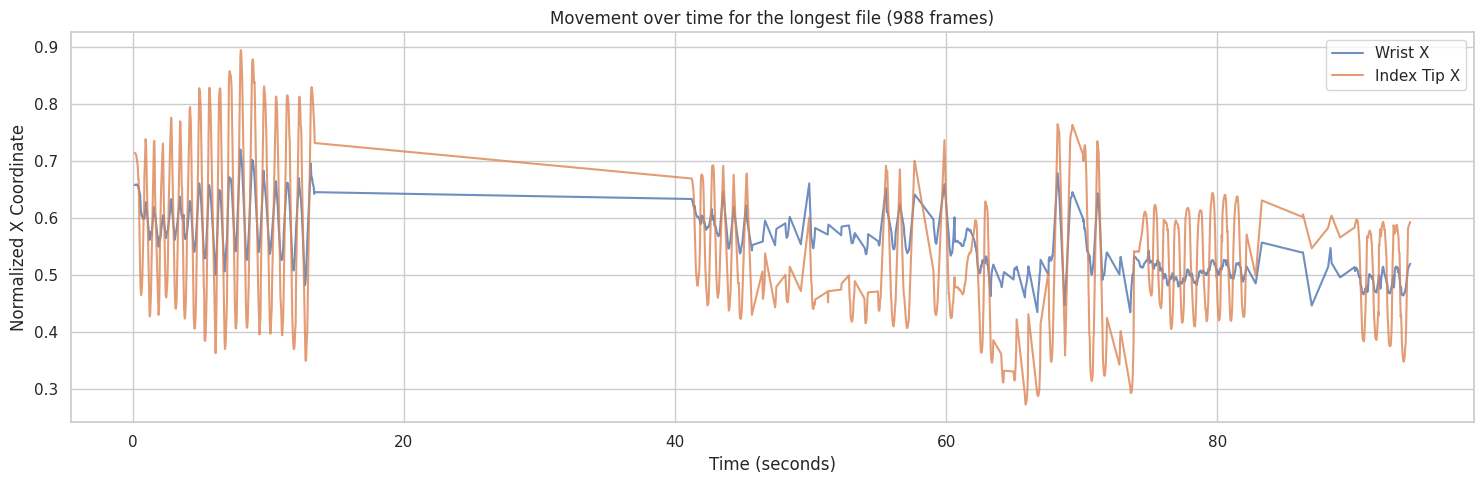

In [23]:
# Visualize the longest file to check for "dead air" (inactivity)
longest_file = raw_summary.sort_values("n_rows", ascending=False).iloc[0]["data_file_name"]
print(f"--- Visualizing the longest recording: {longest_file} ---")

df_long = pd.read_csv(os.path.join(RAW_DIR, longest_file))

# Let's plot a primary hand coordinate (e.g., WRIST.x) and a fingertip
# to see where the actual movement happens.
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df_long["TIME"], df_long["WRIST.x"], label="Wrist X", alpha=0.8)
ax.plot(df_long["TIME"], df_long["INDEX_FINGER_TIP.x"], label="Index Tip X", alpha=0.8)

ax.set_title(f"Movement over time for the longest file ({len(df_long)} frames)")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Normalized X Coordinate")
ax.legend()

plt.tight_layout()
plt.show()

In [24]:
# Check for massive time gaps or frozen frames in the longest file
longest_file = raw_summary.sort_values("n_rows", ascending=False).iloc[0]["data_file_name"]
print(f"--- Diagnosing the flatline in {longest_file} ---")

df_long = pd.read_csv(os.path.join(RAW_DIR, longest_file))

# Calculate time difference between consecutive frames
df_long['dt'] = df_long['TIME'].diff()

# 1. Check for massive time jumps (e.g., gap > 0.5 seconds)
huge_gaps = df_long[df_long['dt'] > 0.5]
print(f"\n1. Found {len(huge_gaps)} time gaps larger than 0.5 seconds:")
if len(huge_gaps) > 0:
    display(huge_gaps[['TIME', 'dt']].head())

# 2. Check for frozen movement (coordinates not changing)
# Calculate absolute difference in WRIST.x and INDEX_FINGER_TIP.x
df_long['wrist_dx'] = df_long['WRIST.x'].diff().abs()
df_long['index_dx'] = df_long['INDEX_FINGER_TIP.x'].diff().abs()

# Frames where movement is practically zero (less than 1e-4)
frozen_frames = df_long[(df_long['wrist_dx'] < 1e-4) & (df_long['index_dx'] < 1e-4)]
print(f"\n2. Found {len(frozen_frames)} frames where the hand is completely frozen.")

--- Diagnosing the flatline in raw_data_8efb0e0b-b097-11ec-bafb-58a023d3f6d9.csv ---

1. Found 26 time gaps larger than 0.5 seconds:


,TIME,dt
239,41.229301,27.798733
317,46.443504,0.743783
323,47.380475,0.740098
327,48.137994,0.663511
338,49.282906,0.821452



2. Found 2 frames where the hand is completely frozen.


--- Extracting longest continuous segment for raw_data_8efb0e0b-b097-11ec-bafb-58a023d3f6d9.csv ---
Original shape: (988, 64) frames
Cleaned shape : (251, 64) frames
Duration of cleaned segment: 8.58 seconds


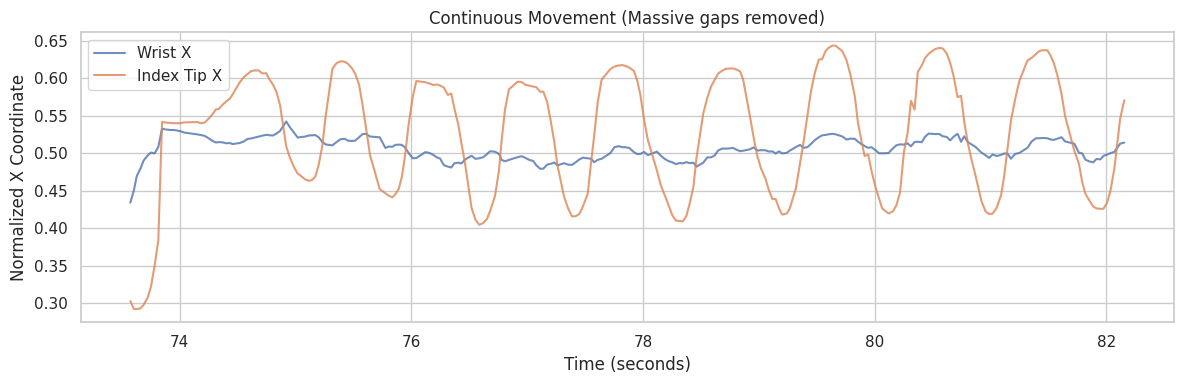

In [25]:
# Function to extract the longest continuous segment from a recording
def get_longest_continuous_segment(df, max_gap_seconds=0.5):
    # Calculate time differences
    df['dt'] = df['TIME'].diff().fillna(0)

    # Identify where gaps exceed the threshold
    # A new segment starts whenever dt > max_gap_seconds
    segment_ids = (df['dt'] > max_gap_seconds).cumsum()

    # Group by segment_id and find the one with the most frames
    longest_segment_id = segment_ids.value_counts().idxmax()

    # Extract the longest segment
    df_longest = df[segment_ids == longest_segment_id].copy()

    # Clean up temporary columns
    df_longest = df_longest.drop(columns=['dt'])

    return df_longest

# 1. Test the extraction on our problematic longest file
print(f"--- Extracting longest continuous segment for {longest_file} ---")
df_long = pd.read_csv(os.path.join(RAW_DIR, longest_file))
print(f"Original shape: {df_long.shape} frames")

df_cleaned = get_longest_continuous_segment(df_long, max_gap_seconds=0.5)
print(f"Cleaned shape : {df_cleaned.shape} frames")
print(f"Duration of cleaned segment: {df_cleaned['TIME'].iloc[-1] - df_cleaned['TIME'].iloc[0]:.2f} seconds")

# 2. Visualize the cleaned version to confirm the "dead air" is gone
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_cleaned["TIME"], df_cleaned["WRIST.x"], label="Wrist X", alpha=0.8)
ax.plot(df_cleaned["TIME"], df_cleaned["INDEX_FINGER_TIP.x"], label="Index Tip X", alpha=0.8)
ax.set_title("Continuous Movement (Massive gaps removed)")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Normalized X Coordinate")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
# 1. Define the output directory for cleaned data
CLEANED_DIR = os.path.join(ROOT, "cleaned_data")
os.makedirs(CLEANED_DIR, exist_ok=True)

# 2. Make sure the function is defined (re-defining to be safe)
def get_longest_continuous_segment(df, max_gap_seconds=0.5):
    df_copy = df.copy()
    df_copy['dt'] = df_copy['TIME'].diff().fillna(0)

    # Identify segments separated by large gaps
    segment_ids = (df_copy['dt'] > max_gap_seconds).cumsum()

    # Extract the segment with the most frames
    longest_segment_id = segment_ids.value_counts().idxmax()
    df_longest = df_copy[segment_ids == longest_segment_id].copy()

    return df_longest.drop(columns=['dt'])

print(f"--- Processing all files and saving to {CLEANED_DIR} ---")

processed_count = 0
dropped_frames_total = 0

# 3. Iterate over all files with a progress bar
for fname in tqdm(raw_names, desc="Cleaning Dataset"):
    in_path = os.path.join(RAW_DIR, fname)
    out_path = os.path.join(CLEANED_DIR, fname)

    # Read the data (which now has corrected TIME for the 43 faulty files)
    df_raw = pd.read_csv(in_path)
    original_len = len(df_raw)

    # Apply the trimming logic
    df_clean = get_longest_continuous_segment(df_raw, max_gap_seconds=0.5)

    # Keep track of how much noise we are removing
    dropped_frames_total += (original_len - len(df_clean))

    # Save the cleaned CSV
    df_clean.to_csv(out_path, index=False)
    processed_count += 1

print(f"\nDone! Successfully cleaned and saved {processed_count} files.")
print(f"Total 'junk' frames completely removed from the dataset: {dropped_frames_total}")

--- Processing all files and saving to /content/drive/MyDrive/medicine/cleaned_data ---


Cleaning Dataset:   0%|          | 0/1214 [00:00<?, ?it/s]


Done! Successfully cleaned and saved 1214 files.
Total 'junk' frames completely removed from the dataset: 21861


In [27]:
import os
import pandas as pd
from tqdm.auto import tqdm

CLEANED_DIR = os.path.join(ROOT, "cleaned_data")
cleaned_files = sorted([f for f in os.listdir(CLEANED_DIR) if f.endswith('.csv')])

files_with_duplicates = []
total_duplicate_rows = 0

print("--- Checking for duplicated timestamps in cleaned_data ---")

for fname in tqdm(cleaned_files, desc="Scanning for duplicates"):
    file_path = os.path.join(CLEANED_DIR, fname)
    df = pd.read_csv(file_path)

    # Count how many duplicated TIME values exist (keeping the first occurrence as 'original')
    dup_count = df['TIME'].duplicated().sum()

    if dup_count > 0:
        files_with_duplicates.append((fname, dup_count))
        total_duplicate_rows += dup_count

print(f"\nTotal files with duplicated timestamps: {len(files_with_duplicates)} / {len(cleaned_files)}")
print(f"Total duplicated rows across all files : {total_duplicate_rows}")

# If we found any, let's peek at the first faulty file
if len(files_with_duplicates) > 0:
    sample_file = files_with_duplicates[0][0]
    print(f"\n--- Snapshot of duplicates in {sample_file} ---")

    df_sample = pd.read_csv(os.path.join(CLEANED_DIR, sample_file))

    # keep=False marks ALL duplicates as True so we can see them grouped together
    duplicated_mask = df_sample['TIME'].duplicated(keep=False)

    # Display the TIME and a few coordinate columns to see if the coordinates are also identical
    display(df_sample[duplicated_mask][['TIME', 'WRIST.x', 'WRIST.y', 'WRIST.z']].head(6))

--- Checking for duplicated timestamps in cleaned_data ---


Scanning for duplicates:   0%|          | 0/1214 [00:00<?, ?it/s]


Total files with duplicated timestamps: 0 / 1214
Total duplicated rows across all files : 0
